<a href="https://colab.research.google.com/github/abhi07dev/AIML-proj/blob/main/Another_copy_of_Untitled23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install opendatasets

In [ ]:
import opendatasets as od
od.download(
    "https://www.kaggle.com/datasets/confirm/google-landmark-dataset-v2-micro"
)


# kaggle dataset link .> https://www.kaggle.com/datasets/confirm/google-landmark-dataset-v2-micro
# use images present in the dataset for prdiction of confidence
# only images present in dataset will predict the class and index of image
# Images which are not present in datasets are not valid for operations

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: abhijitmadne
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/confirm/google-landmark-dataset-v2-micro


100%|██████████| 3.03G/3.03G [00:28<00:00, 112MB/s]


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
base_dir="/content/google-landmark-dataset-v2-micro/gldv2_micro/images"
train_dir=os.path.join(base_dir,"TRAIN")
test_dir=os.path.join(base_dir,"TEST")

train_datagen=ImageDataGenerator(rescale=1./255)
test_datagen=ImageDataGenerator(rescale=1./255)

In [ ]:
import pandas as pd


image_base_dir = "/content/google-landmark-dataset-v2-micro/gldv2_micro/images"


train_df = pd.read_csv("/content/google-landmark-dataset-v2-micro/gldv2_micro/train.csv")
val_df = pd.read_csv("/content/google-landmark-dataset-v2-micro/gldv2_micro/val.csv")




train_df['landmark_id'] = train_df['landmark_id'].astype(str)
val_df['landmark_id'] = val_df['landmark_id'].astype(str)

train_data = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=image_base_dir,
    x_col="filename",
    y_col="landmark_id",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    seed=42
)

test_data = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=image_base_dir,
    x_col="filename",
    y_col="landmark_id",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    seed=42
)

Found 23294 validated image filenames belonging to 3103 classes.
Found 3103 validated image filenames belonging to 3103 classes.


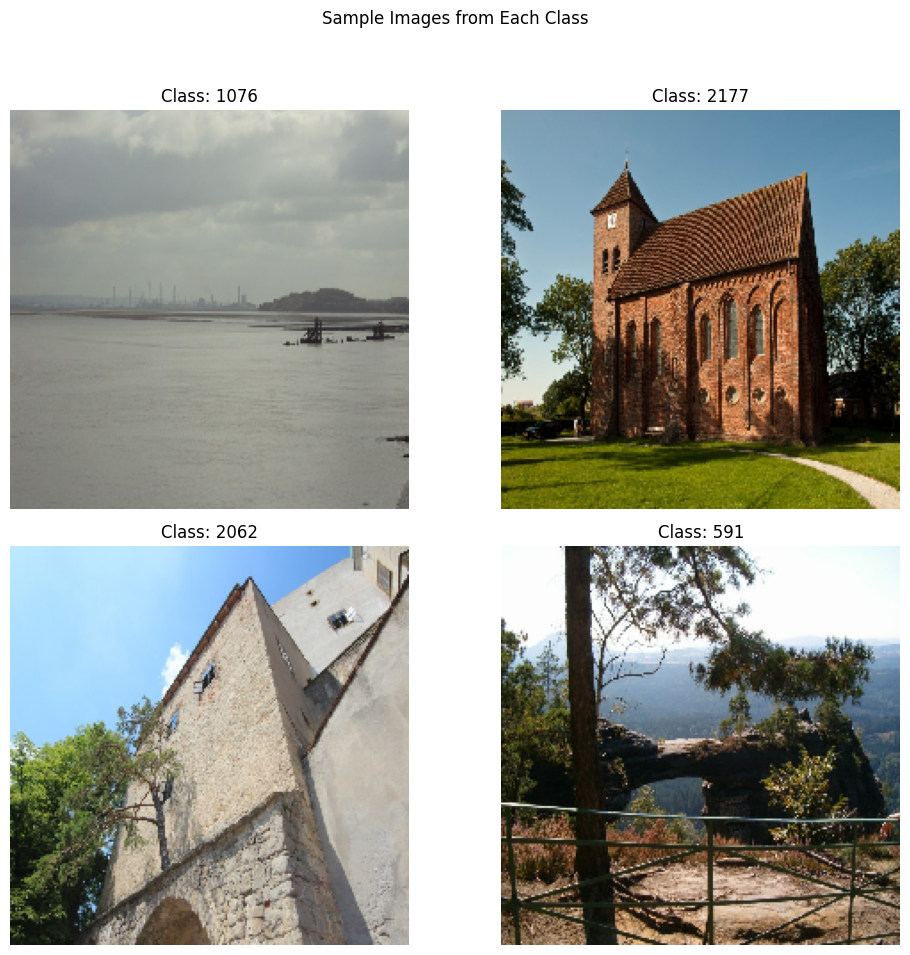

In [ ]:
plt.figure(figsize=(10, 10))


class_names = {v: k for k, v in train_data.class_indices.items()}

for i in range(4):
    image_batch, label_batch = next(train_data)
    plt.subplot(2, 2, i + 1)
    plt.imshow(image_batch[0])


    predicted_class_index = np.argmax(label_batch[0])
    actual_landmark_id = class_names[predicted_class_index]

    plt.title(f"Class: {actual_landmark_id}")
    plt.axis('off')
plt.suptitle("Sample Images from Each Class")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
mobilenet_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
mobilenet_model.trainable = False


num_classes = len(class_names)


model = tf.keras.Sequential([
    mobilenet_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=2
)


model.save('mobilenet_waste_classifier.h5')

loss, accuracy = model.evaluate(test_data)
print("Model Accuracy:", accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2
728/728 ━━━━━━━━━━━━━━━━━━━━ 178s 220ms/step - accuracy: 0.0700 - loss: 7.7368 - val_accuracy: 0.2372 - val_loss: 4.7200
Epoch 2/2
728/728 ━━━━━━━━━━━━━━━━━━━━ 120s 165ms/step - accuracy: 0.7273 - loss: 1.4864 - val_accuracy: 0.3149 - val_loss: 4.3325


97/97 ━━━━━━━━━━━━━━━━━━━━ 13s 138ms/step - accuracy: 0.3179 - loss: 4.3503
Model Accuracy: 0.3148565888404846


Upload image files (JPEG/PNG) to classify:


Saving fffeb227421ee4e6.jpg to fffeb227421ee4e6.jpg

 Processing: fffeb227421ee4e6.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
 Predicted class: 664
 Index: 2731
 Confidence: 62.49%


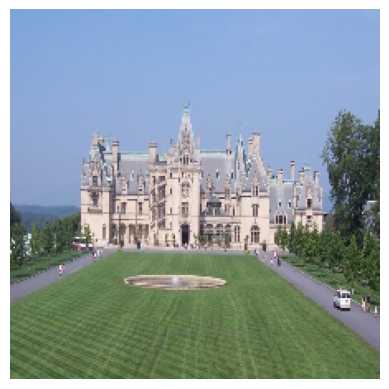

In [ ]:

import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt


print("Upload image files (JPEG/PNG) to classify:")
uploaded = files.upload()


CONFIDENCE_THRESHOLD = .303

for filename in uploaded.keys():
    print(f"\n Processing: {filename}")


    img_path = '/content/' + filename
    img = image.load_img(img_path, target_size=(224, 224))


    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = x / 255.0


    preds = model.predict(x)
    predicted_class_index = np.argmax(preds, axis=1)[0]
    confidence = np.max(preds)


    if confidence < CONFIDENCE_THRESHOLD:
        print(" Prediction class does not exist")
        print(" Index does not exist")
        print(f" (Confidence was too low: {confidence:.2%})")
    else:
        try:
            class_name = class_names[predicted_class_index]
        except KeyError:
            class_name = str(predicted_class_index)
        print(f" Predicted class: {class_name}")
        print(f" Index: {predicted_class_index}")
        print(f" Confidence: {confidence:.2%}")


    plt.imshow(img)
    plt.axis('off')
    plt.show()



    # kaggle dataset link .> https://www.kaggle.com/datasets/confirm/google-landmark-dataset-v2-micro